<a href="https://colab.research.google.com/github/APMAPM1/Tech-Gadget-Consumption_2015-2025/blob/develop%2Ftech_gadget_consumption/Tech_Gadget_Consumption_(2015_2025).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Tech Gadget Consumption (2015 - 2025)**

**Overview**

Technology adoption has been evolving rapidly, shaping industries and consumer behaviors worldwide. This project leverages a dataset covering global gadget consumption trends from 2015 to 2025.

The data encompasses key technologies such as smartphones, laptops, gaming consoles, smartwatches, and the rising adoption of 5G. Your task as an intern will be to apply machine learning techniques to evaluate and forecast trends using the provided dataset.

**Dataset Description**

- Country: Country where data is recorded 🌍
- Year: Year of observation 📅
- Smartphone Sales (Million): Number of smartphones sold (in millions) 📱
- Laptop Shipments (Million): Number of laptops shipped (in millions) 💻
- Gaming Console Adoption (%): Percentage of population using gaming consoles 🎮
- Smartwatch Penetration (%): Percentage of population using smartwatches ⌚
- Avg Consumer Spending ($): Average spending on tech gadgets 💵
- E-Waste Generation (KT): E-waste generated in kilotons (KT) ♻️
- 5G Penetration (%): Percentage of population with 5G access 📡


# **Loading Dataset and data collection**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
file_path = '/content/drive/MyDrive/Datasets/Global_Tech_Gadget_Consumption.csv'

In [5]:
df = pd.read_csv(file_path)
df.head()

,Country,Year,Smartphone Sales (Millions),Laptop Shipments (Millions),Gaming Console Adoption (%),Smartwatch Penetration (%),Average Consumer Spending on Gadgets ($),E-Waste Generated (Metric Tons),5G Penetration Rate (%)
0,USA,2015,111.37,123.63,12.05,14.49,311.21,939.89,54.64
1,USA,2016,224.65,65.27,12.92,9.88,250.46,1361.42,53.61
2,USA,2017,102.12,26.75,19.63,17.35,2404.22,872.52,29.94
3,USA,2018,148.10,129.28,26.44,12.45,1883.37,1241.41,75.88
4,USA,2019,83.93,97.81,20.84,6.18,777.42,1939.39,76.26


In [6]:
df.columns

Index(['Country', 'Year', 'Smartphone Sales (Millions)',
       'Laptop Shipments (Millions)', 'Gaming Console Adoption (%)',
       'Smartwatch Penetration (%)',
       'Average Consumer Spending on Gadgets ($)',
       'E-Waste Generated (Metric Tons)', '5G Penetration Rate (%)'],
      dtype='object')

In [7]:
df.shape

(110, 9)

In [8]:
df.describe()

,Year,Smartphone Sales (Millions),Laptop Shipments (Millions),Gaming Console Adoption (%),Smartwatch Penetration (%),Average Consumer Spending on Gadgets ($),E-Waste Generated (Metric Tons),5G Penetration Rate (%)
count,110.00000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000,110.000000
mean,2020.00000,269.095545,86.082000,21.753545,14.129818,1571.539182,1035.352636,42.816273
std,3.17675,128.313552,36.429392,9.748557,6.353190,816.552255,562.591157,21.888573
min,2015.00000,64.000000,20.790000,5.490000,2.040000,220.090000,111.470000,2.990000
25%,2017.00000,156.910000,59.412500,13.737500,8.982500,856.957500,570.250000,23.952500
50%,2020.00000,253.435000,87.450000,20.365000,14.520000,1592.145000,1023.270000,45.735000
75%,2023.00000,376.255000,113.965000,28.460000,19.815000,2195.960000,1487.847500,58.900000
max,2025.00000,499.890000,149.210000,39.470000,24.810000,2989.540000,1962.590000,79.340000


In [9]:
df.describe(include=['object'])

,Country
count,110
unique,10
top,USA
freq,11


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Country                                   110 non-null    object 
 1   Year                                      110 non-null    int64  
 2   Smartphone Sales (Millions)               110 non-null    float64
 3   Laptop Shipments (Millions)               110 non-null    float64
 4   Gaming Console Adoption (%)               110 non-null    float64
 5   Smartwatch Penetration (%)                110 non-null    float64
 6   Average Consumer Spending on Gadgets ($)  110 non-null    float64
 7   E-Waste Generated (Metric Tons)           110 non-null    float64
 8   5G Penetration Rate (%)                   110 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 7.9+ KB


In [11]:
df.nunique()

,0
Country,10
Year,11
Smartphone Sales (Millions),109
Laptop Shipments (Millions),110
Gaming Console Adoption (%),106
Smartwatch Penetration (%),108
Average Consumer Spending on Gadgets ($),110
E-Waste Generated (Metric Tons),110
5G Penetration Rate (%),110


# **Data Preparation**

In [12]:
df.isnull().sum()

,0
Country,0
Year,0
Smartphone Sales (Millions),0
Laptop Shipments (Millions),0
Gaming Console Adoption (%),0
Smartwatch Penetration (%),0
Average Consumer Spending on Gadgets ($),0
E-Waste Generated (Metric Tons),0
5G Penetration Rate (%),0


In [13]:
df.duplicated().sum()

np.int64(0)

## **Data Insights**

Overall Insights

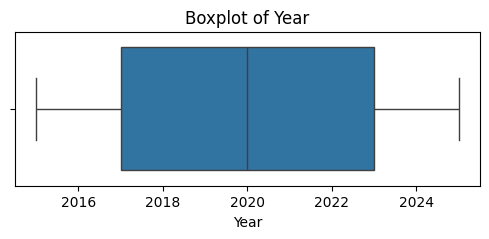

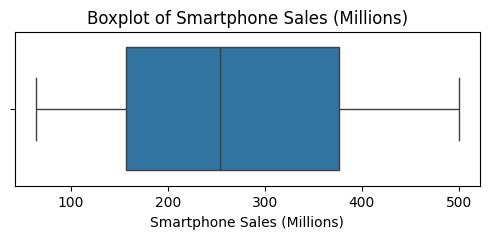

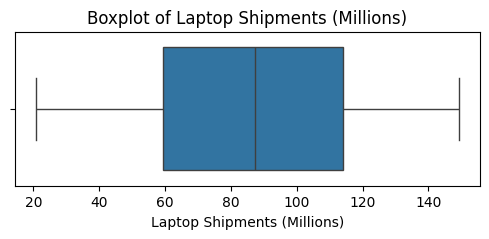

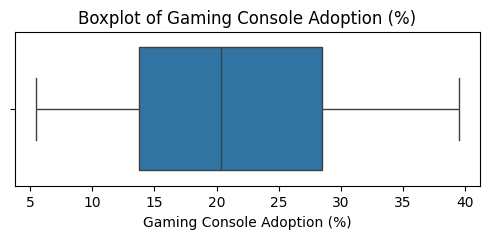

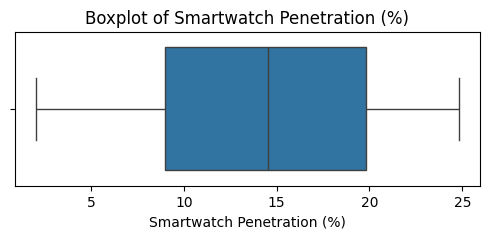

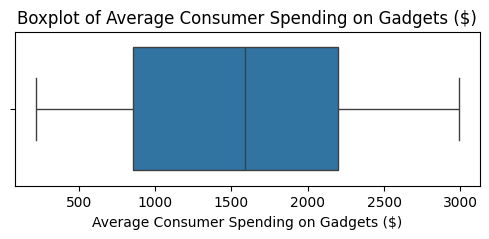

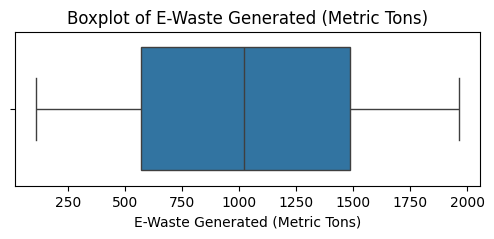

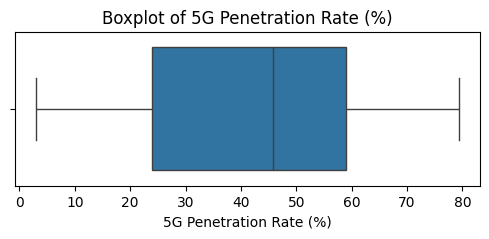

In [14]:
numerical_cols = df.select_dtypes(include=['int64', 'float64'])
for col in numerical_cols:
  plt.figure(figsize=(6, 2))
  sns.boxplot(x=df[col])
  plt.title(f"Boxplot of {col}")
  plt.show()

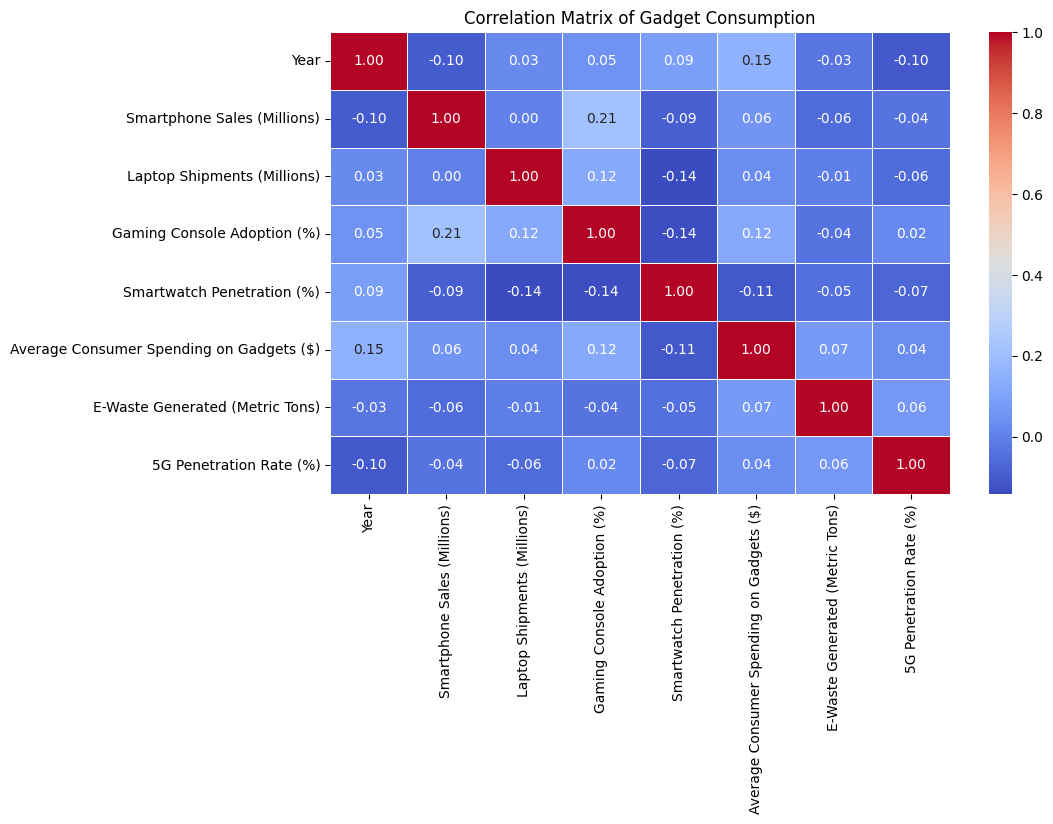

In [15]:
plt.figure(figsize=(10, 6))
numerical_cols = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Gadget Consumption")
plt.show()

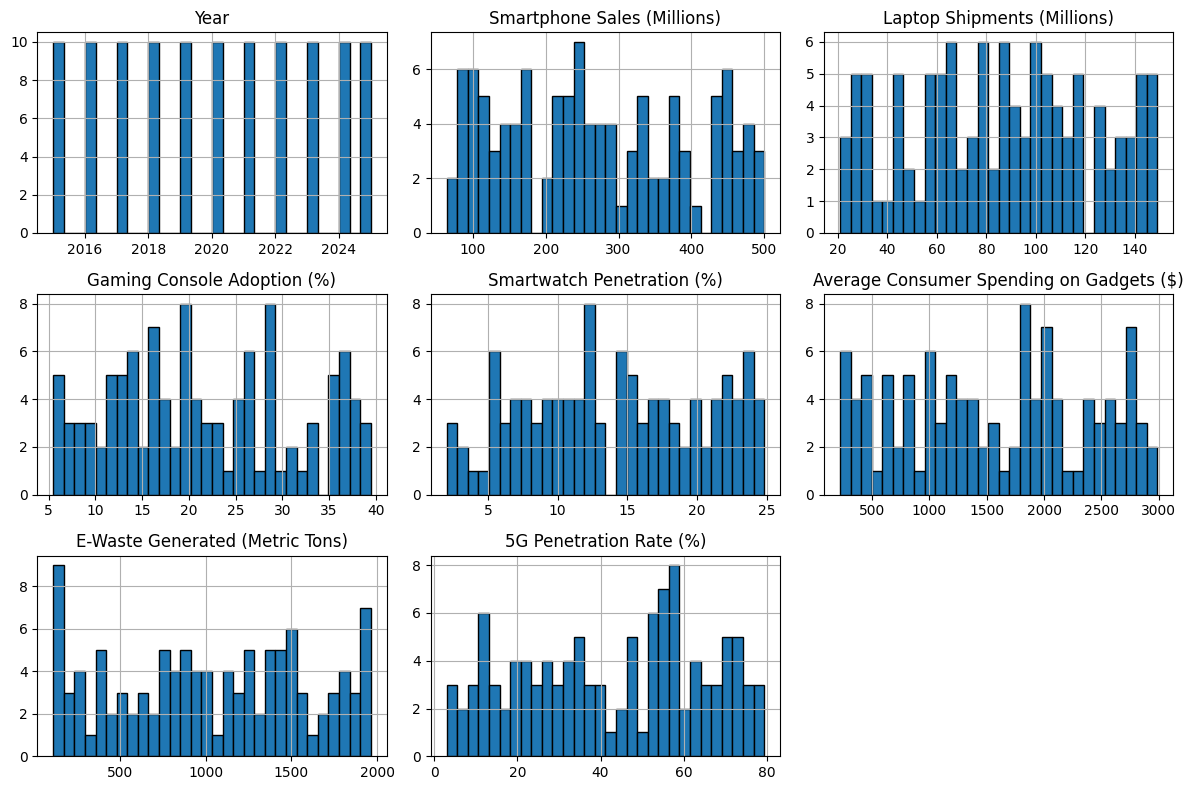

In [16]:
df.hist(figsize=(12, 8), bins=30, edgecolor="black")
plt.tight_layout()
plt.show()

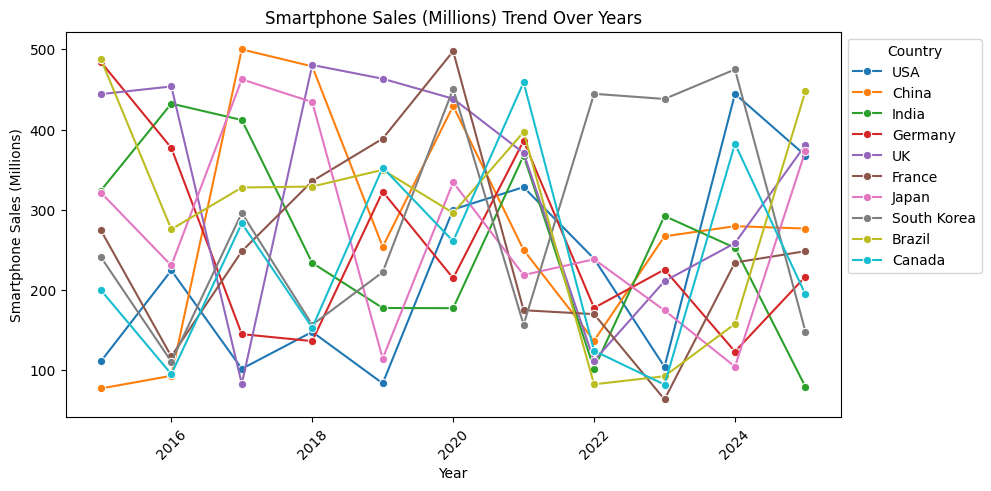

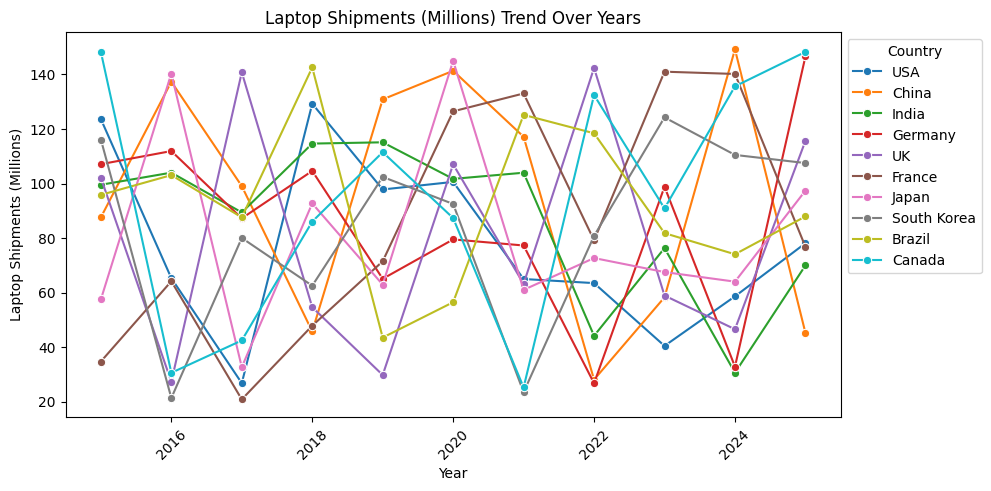

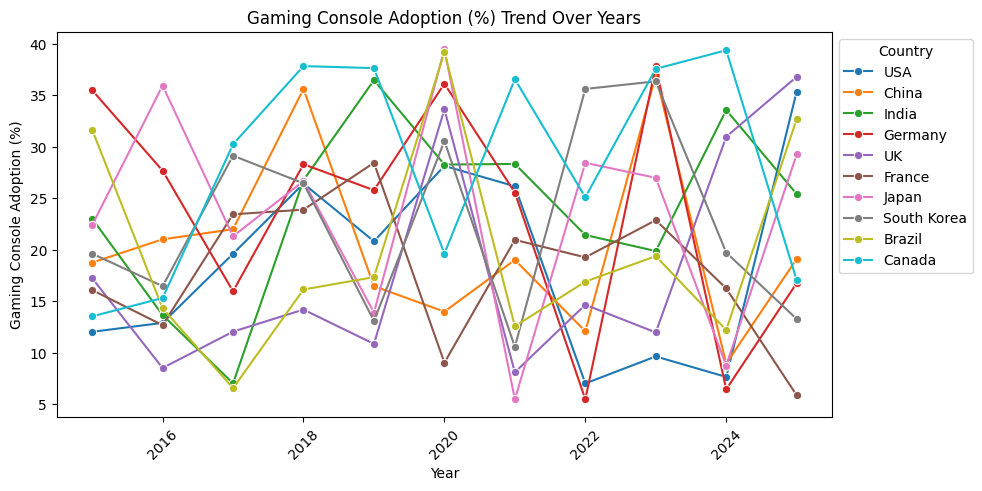

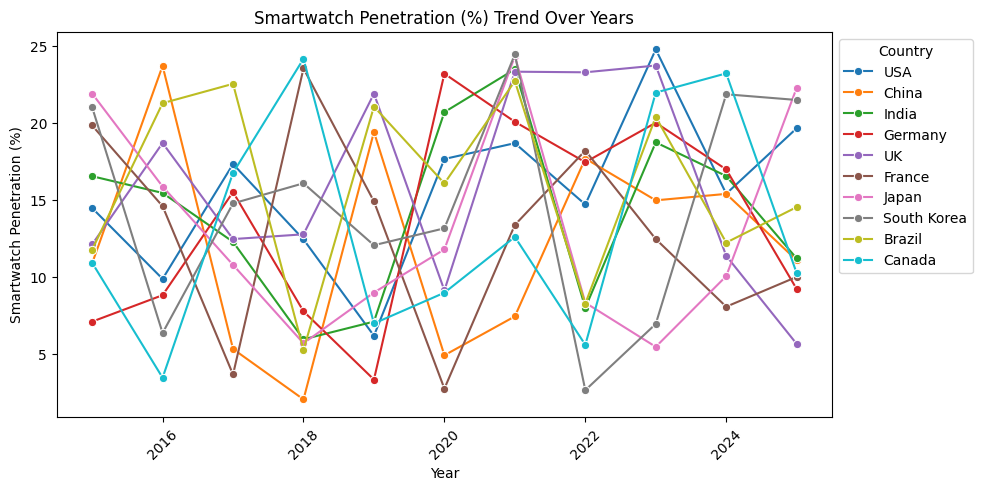

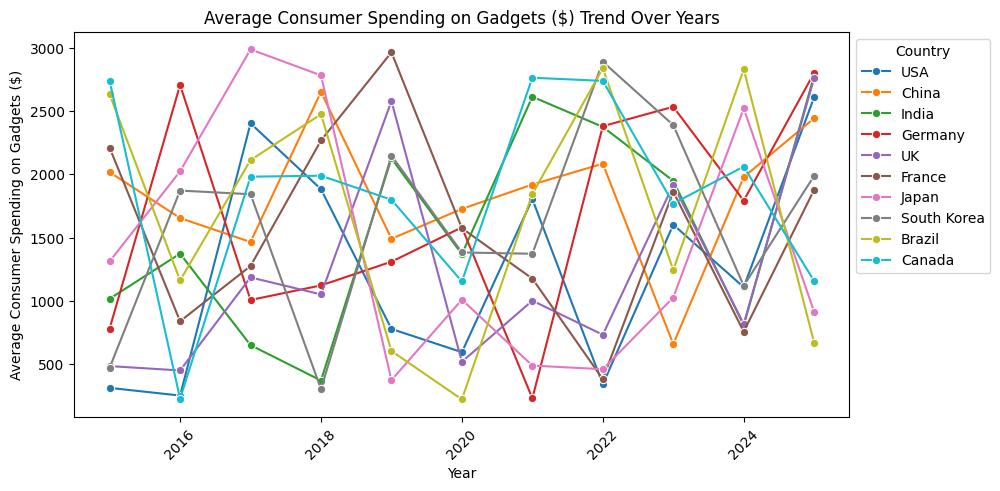

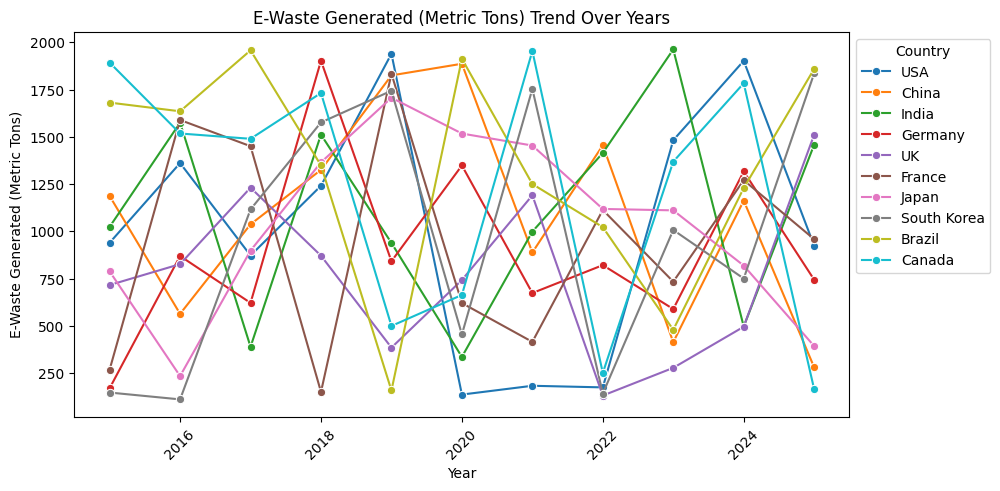

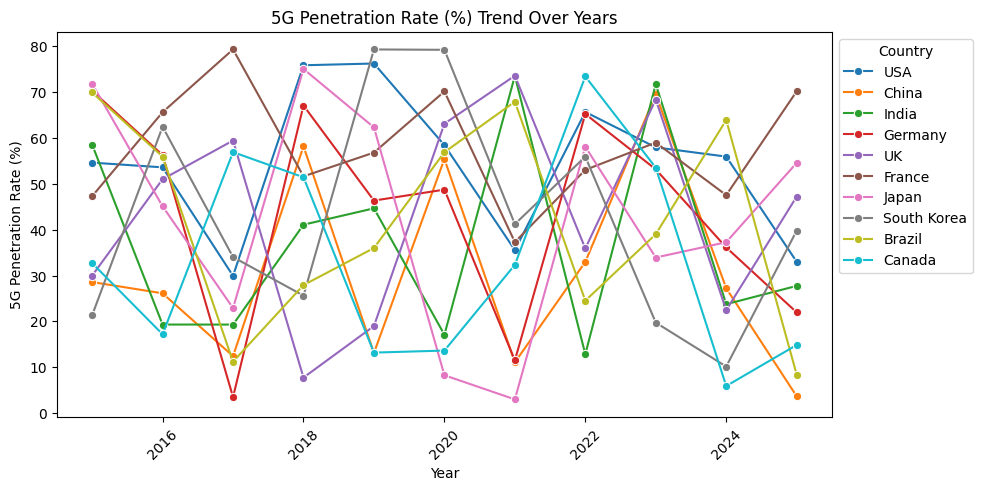

In [17]:
columns_to_plot = [
    "Smartphone Sales (Millions)",
    "Laptop Shipments (Millions)",
    "Gaming Console Adoption (%)",
    "Smartwatch Penetration (%)",
    "Average Consumer Spending on Gadgets ($)",
    "E-Waste Generated (Metric Tons)",
    "5G Penetration Rate (%)"

]

if "Year" in df.columns:
    for col in columns_to_plot:
        if col in df.columns:
            plt.figure(figsize=(10, 5))
            sns.lineplot(x="Year", y=col, data=df, hue="Country", marker="o")
            plt.title(f"{col} Trend Over Years")
            plt.xlabel("Year")
            plt.ylabel(f"{col}")
            plt.xticks(rotation=45)
            plt.legend(title="Country", bbox_to_anchor=(1, 1))
            plt.show()


Individual Columns

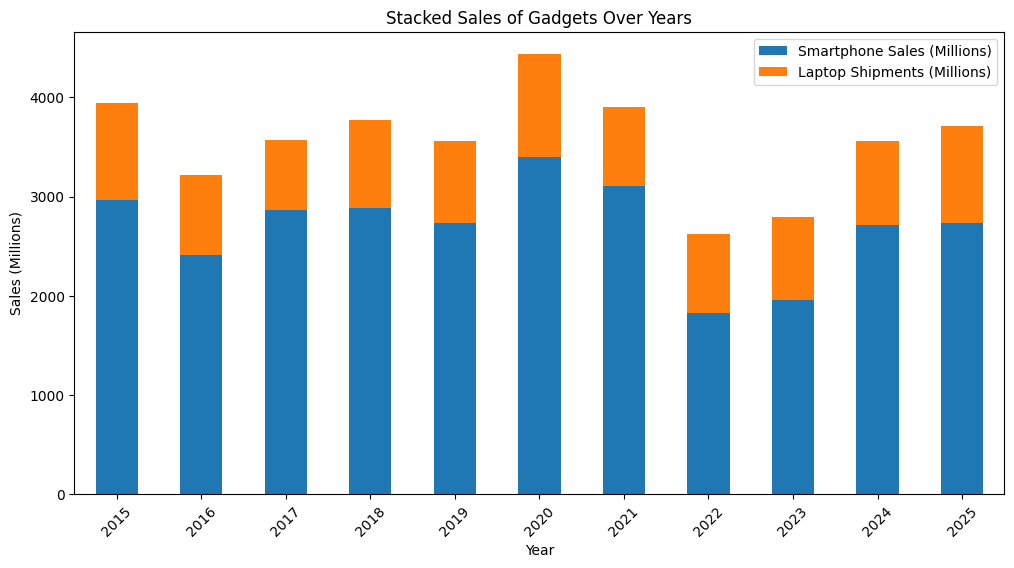

In [18]:
df_grouped = df.groupby("Year")[["Smartphone Sales (Millions)", "Laptop Shipments (Millions)"]].sum()

df_grouped.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Stacked Sales of Gadgets Over Years")
plt.ylabel("Sales (Millions)")
plt.xticks(rotation=45)
plt.show()

In [19]:
import plotly.express as px

# Ensure 'Year' is treated as a categorical variable
df["Year"] = df["Year"].astype(str)

# Create animated choropleth map
fig = px.choropleth(df,
                    locations="Country",
                    locationmode="country names",
                    color="Smartphone Sales (Millions)",
                    hover_name="Country",
                    animation_frame="Year",  # Animation by year
                    title="Smartphone Sales by Country Over Time",
                    color_continuous_scale="viridis")

# Show the figure
fig.show()


In [20]:
import plotly.express as px

# Ensure 'Year' is treated as a categorical variable
df["Year"] = df["Year"].astype(str)

# Create animated choropleth map
fig = px.choropleth(df,
                    locations="Country",
                    locationmode="country names",
                    color="Laptop Shipments (Millions)",
                    hover_name="Country",
                    animation_frame="Year",  # Animation by year
                    title="Laptop Shipments by Country Over Time",
                    color_continuous_scale="viridis")

# Show the figure
fig.show()


In [21]:
import plotly.express as px

df["Year"] = df["Year"].astype(str)  # Ensure Year is a string for animation

# Gaming Console Adoption Map
fig = px.choropleth(df,
                     locations="Country",
                     locationmode="country names",
                     color="Gaming Console Adoption (%)",
                     hover_name="Country",
                     animation_frame="Year",
                     title="Gaming Console Adoption by Country Over Time",
                     color_continuous_scale="viridis")
fig.show()



In [22]:
import plotly.express as px

df["Year"] = df["Year"].astype(str)  # Ensure Year is a string for animation

# Smartwatch Penetration Map
fig = px.choropleth(df,
                     locations="Country",
                     locationmode="country names",
                     color="Smartwatch Penetration (%)",
                     hover_name="Country",
                     animation_frame="Year",
                     title="Smartwatch Penetration by Country Over Time",
                     color_continuous_scale="plasma")
fig.show()


In [23]:
import plotly.express as px

df["Year"] = df["Year"].astype(str)  # Ensure Year is a string for animation

fig = px.choropleth(df,
                    locations="Country",
                    locationmode="country names",
                    color="Average Consumer Spending on Gadgets ($)",
                    hover_name="Country",
                    animation_frame="Year",
                    title="Average Consumer Spending on Gadgets by Country Over Time",
                    color_continuous_scale="blues")

fig.show()


In [24]:
import plotly.express as px

df["Year"] = df["Year"].astype(str)  # Ensure Year is a string for animation

fig = px.choropleth(df,
                    locations="Country",
                    locationmode="country names",
                    color="E-Waste Generated (Metric Tons)",
                    hover_name="Country",
                    animation_frame="Year",
                    title="E-Waste Generation by Country Over Time",
                    color_continuous_scale="reds")

fig.show()


In [25]:
import plotly.express as px

df["Year"] = df["Year"].astype(str)  # Ensure Year is a string for animation

fig = px.choropleth(df,
                    locations="Country",
                    locationmode="country names",
                    color="5G Penetration Rate (%)",
                    hover_name="Country",
                    animation_frame="Year",
                    title="5G Penetration Rate by Country Over Time",
                    color_continuous_scale="plasma")

fig.show()
